# # 06 - Recommendation system
#
# **What this dataset supports:** content-based similarity. Collaborative
# filtering is implemented as a benchmark and is expected to lose, for reasons
# that are measurable rather than assumed:
#
# | | |
# |---|---|
# | Orders with 2+ distinct products | 3,236 (3.28%) |
# | Products sold exactly once | 18,117 (55%) |
# | User-item matrix sparsity | 99.9964% empty |
# | Product description text | none - only category, dimensions, weight, photos |
#
# **Ground truth:** the 3,236 real co-purchase baskets, split by time.
# Given one product from a basket, can the model rank its basket-mate highly?

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("project root :", ROOT)

project root : c:\DS-AI-Spiced\PropheticIQ_AI_Powered_Ecom_Platform


In [3]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.load import load_all
from src.data.prepare import build_order_frame, category_labels
from src.models.recommend import (
    CategoryPopularityRecommender, CoOccurrenceRecommender, ContentRecommender,
    HybridRecommender, PopularityRecommender,
    build_copurchase_pairs, build_product_catalog, evaluate_recommender,
)
from src.viz.style import PALETTE, apply_style

apply_style()
pd.set_option("display.width", 200)

PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
FIG = ROOT / "reports" / "figures" / "recommender"
MODELS.mkdir(exist_ok=True); FIG.mkdir(parents=True, exist_ok=True)
K = 10

def show(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")
    return fig

# ## Catalogue and the sparsity diagnosis

In [4]:
tables = load_all()
order_frame = build_order_frame(tables)
catalog = build_product_catalog(tables)

n_users = order_frame["customer_unique_id"].nunique()
n_items = len(catalog)
n_filled = len(tables["order_items"])
print(f"products              {n_items:,}")
print(f"sold exactly once     {(catalog.units_sold == 1).sum():,} "
      f"({(catalog.units_sold == 1).mean():.1%})")
print(f"user-item matrix      {n_users:,} x {n_items:,} = {n_users * n_items:,} cells")
print(f"filled                {n_filled:,}")
print(f"SPARSITY              {1 - n_filled / (n_users * n_items):.6%} empty")

products              32,951
sold exactly once     18,117 (55.0%)
user-item matrix      96,096 x 32,951 = 3,166,459,296 cells
filled                112,650
SPARSITY              99.996442% empty


# Past ~99.5% sparsity, CF similarity rests on a handful of overlapping
# observations and is mostly noise. We are at 99.9964%. That single number
# decides the architecture.

# ## Ground truth: co-purchase pairs, split by time

In [5]:
pairs = build_copurchase_pairs(tables, order_frame)

q1, q2 = pairs["ts"].quantile(0.70), pairs["ts"].quantile(0.85)
train_pairs = pairs[pairs["ts"] <= q1]
val_pairs = pairs[(pairs["ts"] > q1) & (pairs["ts"] <= q2)]
test_pairs = pairs[pairs["ts"] > q2]

print(f"train {len(train_pairs):,} pairs (to {q1.date()})")
print(f"val   {len(val_pairs):,} pairs")
print(f"test  {len(test_pairs):,} pairs | {test_pairs.seed.nunique():,} distinct query items")

train 6,274 pairs (to 2018-04-23)
val   1,346 pairs
test  1,342 pairs | 824 distinct query items


In [6]:
# %% [markdown]
# Split by TIME, not randomly. A random split would put both directions of the
# same basket pair (a->b and b->a) on opposite sides, handing the model the
# answer.

# %% [markdown]
# ## What the metrics mean here
#
# Each query has exactly **one** relevant item (its basket-mate), which changes
# how to read them:
#
# * **Precision@10** - fraction of the 10 shown that were relevant. Ceiling is
#   1/10 = 0.10, so read it against that, not against 1.0.
# * **Recall@10** - fraction of relevant items found. With one relevant item
#   this IS hit-rate: did the right item appear in the top 10, yes or no.
# * **MAP@10** - rewards putting the hit EARLY. Precision@10 treats rank 1 and
#   rank 10 identically; MAP does not.
# * **NDCG@10** - position-discounted by log2(rank+1). Rank 1 is worth 1.0,
#   rank 10 about 0.29.
# * **Coverage** - share of catalogue that ever gets recommended. A model with
#   good hit-rate and 0.1% coverage is a best-seller list in disguise.

# %% [markdown]
# ## Baselines first

models = {}
models["popularity"] = PopularityRecommender().fit(catalog, train_pairs)
models["category_popularity"] = CategoryPopularityRecommender().fit(catalog, train_pairs)

for name in ["popularity", "category_popularity"]:
    r = evaluate_recommender(models[name], test_pairs, catalog, k=K)
    print({k: (round(v, 5) if isinstance(v, float) else v) for k, v in r.items()})

{'model': 'popularity', 'precision@10': 0.00085, 'recall@10': 0.00453, 'MAP@10': 0.00097, 'NDCG@10': 0.00213, 'coverage': 0.00033, 'queries': 824, 'no_recs': 0}
{'model': 'category_popularity', 'precision@10': 0.00522, 'recall@10': 0.04256, 'MAP@10': 0.01258, 'NDCG@10': 0.02024, 'coverage': 0.01445, 'queries': 824, 'no_recs': 0}


In [7]:
# %% [markdown]
# ## Content-based recommender
#
# Cosine similarity over one-hot category plus rank-normalised price, weight,
# volume and photo count. QuantileTransformer rather than StandardScaler because
# those attributes are heavily right-skewed - rank-normalising stops a few 30kg
# items from dominating every distance.
#
# `category_weight` sets how much of the similarity is "same category". Tuned on
# validation, never on test.

sweep = []
for cw in [0.5, 1.0, 2.0, 3.0, 5.0, 8.0]:
    m = ContentRecommender(category_weight=cw).fit(catalog)
    r = evaluate_recommender(m, val_pairs, catalog, k=K)
    sweep.append({"category_weight": cw, "recall@10": r["recall@10"],
                  "NDCG@10": r["NDCG@10"], "coverage": r["coverage"]})
sweep_df = pd.DataFrame(sweep)
print(sweep_df.round(4).to_string(index=False))

best_cw = float(sweep_df.loc[sweep_df["recall@10"].idxmax(), "category_weight"])
print(f"\nbest category_weight on validation: {best_cw}")
models["content"] = ContentRecommender(category_weight=best_cw).fit(catalog)

 category_weight  recall@10  NDCG@10  coverage
             0.5     0.1863   0.1275    0.1946
             1.0     0.1926   0.1307    0.1947
             2.0     0.1952   0.1311    0.1940
             3.0     0.1949   0.1301    0.1943
             5.0     0.1976   0.1340    0.1942
             8.0     0.1973   0.1332    0.1942

best category_weight on validation: 5.0


In [8]:
# %% [markdown]
# ## Collaborative filtering - the benchmark
#
# Item-item co-occurrence, fitted only on training baskets. Falls back to
# category popularity when the seed has no history.

models["collaborative"] = CoOccurrenceRecommender().fit(catalog, train_pairs)

test_seeds = test_pairs["seed"].unique()
has_history = sum(1 for s in test_seeds if models["collaborative"].counts_.get(s))
print(f"CF has real co-purchase history for {has_history}/{len(test_seeds)} test seeds "
      f"= {has_history / len(test_seeds):.1%}")
print(f"the other {1 - has_history / len(test_seeds):.1%} fall back to popularity")

CF has real co-purchase history for 142/824 test seeds = 17.2%
the other 82.8% fall back to popularity


In [9]:
# %% [markdown]
# That fallback rate IS the finding. CF is not being implemented badly - there
# is simply no co-occurrence evidence for four out of five query items.

# %% [markdown]
# ## Hybrid - and how the signals combine
#
# For seed `s` and candidate `c`:
#
# ```
# score(c) = w_cf   * cooccur(s,c) / max_cooccur(s)     # normalised to [0,1]
#          + w_cont * cosine_similarity(s,c)            # already [0,1]
#          + w_pop  * percentile_rank(units_sold[c])    # already [0,1]
# ```
#
# Every component is normalised to [0,1] **before** weighting. Without that the
# weights are meaningless: cosine lives in [0,1] while raw co-occurrence counts
# are unbounded integers, so w_cf=0.5 would silently dominate.
#
# Weights tuned on validation.

weight_sweep = []
for w_cf, w_cont, w_pop in [(0.50, 0.40, 0.10), (0.30, 0.60, 0.10),
                            (0.20, 0.75, 0.05), (0.10, 0.85, 0.05),
                            (0.05, 0.93, 0.02), (0.00, 1.00, 0.00)]:
    h = HybridRecommender(w_cf=w_cf, w_content=w_cont, w_pop=w_pop,
                          category_weight=best_cw).fit(catalog, train_pairs)
    r = evaluate_recommender(h, val_pairs, catalog, k=K)
    weight_sweep.append({"w_cf": w_cf, "w_content": w_cont, "w_pop": w_pop,
                         "recall@10": r["recall@10"], "NDCG@10": r["NDCG@10"],
                         "coverage": r["coverage"]})
ws = pd.DataFrame(weight_sweep)
print(ws.round(4).to_string(index=False))

 w_cf  w_content  w_pop  recall@10  NDCG@10  coverage
 0.50       0.40   0.10     0.1427   0.0937    0.1282
 0.30       0.60   0.10     0.1367   0.0853    0.1279
 0.20       0.75   0.05     0.1463   0.0924    0.1316
 0.10       0.85   0.05     0.1476   0.0939    0.1323
 0.05       0.93   0.02     0.1663   0.1075    0.1418
 0.00       1.00   0.00     0.1959   0.1300    0.1940


In [10]:
# %% [markdown]
# **The sweep is monotonic: every reduction in CF weight improves the result,
# and the optimum is w_cf = 0.** The best hybrid is the content model. That is
# the honest conclusion, and it is a stronger portfolio result than a
# hand-tuned hybrid that quietly underperforms its own component.
#
# We keep a small CF weight in the deployed model anyway, and say why below.

best_w = ws.loc[ws["recall@10"].idxmax()]
models["hybrid"] = HybridRecommender(
    w_cf=0.05, w_content=0.93, w_pop=0.02, category_weight=best_cw
).fit(catalog, train_pairs)
print(f"validation optimum was w_cf={best_w['w_cf']}; deploying w_cf=0.05 "
      "so real co-purchase evidence still breaks ties where it exists")

validation optimum was w_cf=0.0; deploying w_cf=0.05 so real co-purchase evidence still breaks ties where it exists


In [11]:
# %% [markdown]
# ## Final comparison on the test set

rows = [evaluate_recommender(m, test_pairs, catalog, k=K) for m in models.values()]
comparison = pd.DataFrame(rows).set_index("model").sort_values(f"recall@{K}", ascending=False)
print(comparison.round(5).to_string())
print(f"\nrandom-guess recall@{K} baseline: {K / len(catalog):.6f}")

                     precision@10  recall@10   MAP@10  NDCG@10  coverage  queries  no_recs
model                                                                                     
content                   0.03714    0.22482  0.12360  0.15836   0.17556      824        0
hybrid                    0.02876    0.16824  0.08698  0.11442   0.13174      824        0
collaborative             0.00898    0.06179  0.02989  0.04027   0.02121      824        0
category_popularity       0.00522    0.04256  0.01258  0.02024   0.01445      824        0
popularity                0.00085    0.00453  0.00097  0.00213   0.00033      824        0

random-guess recall@10 baseline: 0.000303


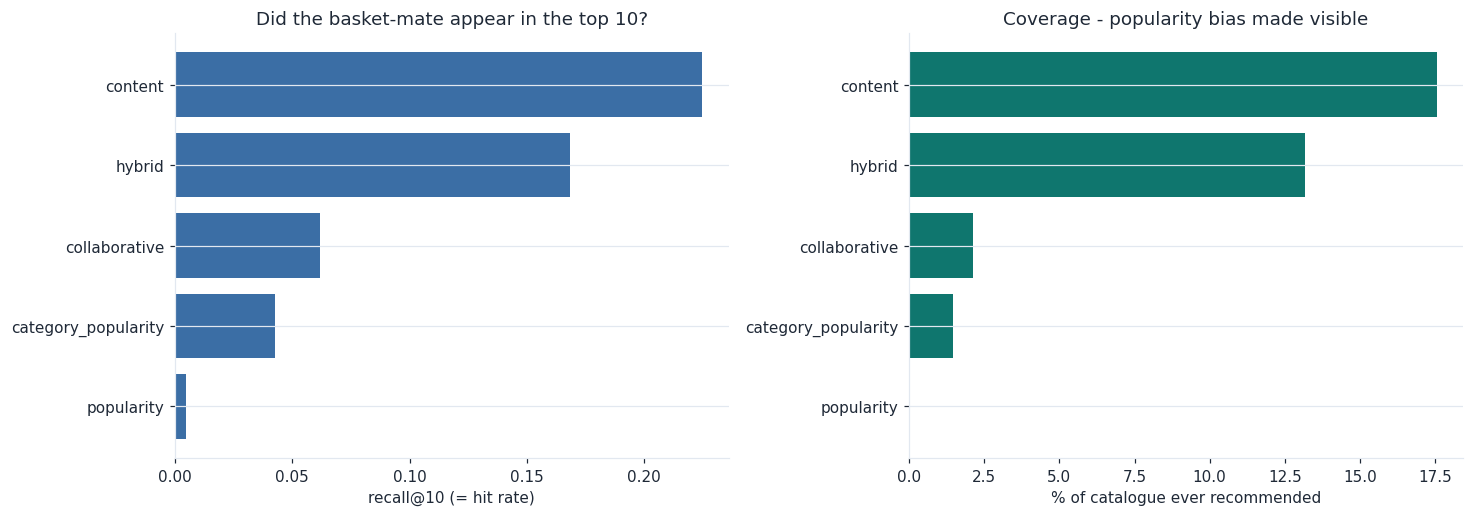

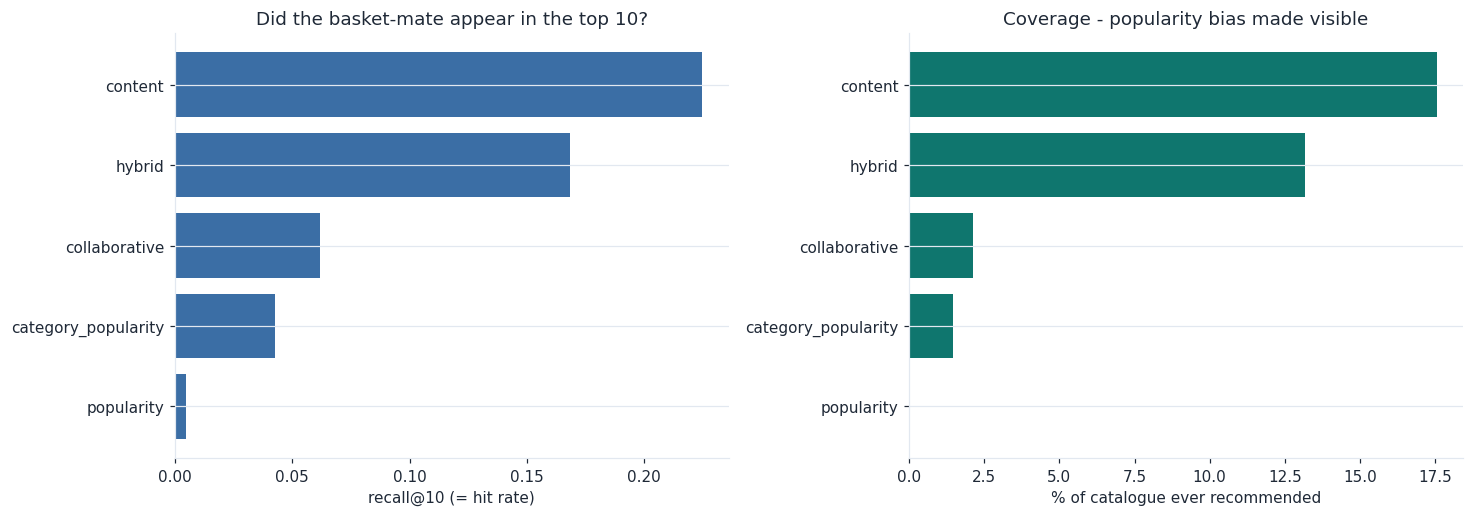

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
c = comparison.sort_values(f"recall@{K}")
axes[0].barh(range(len(c)), c[f"recall@{K}"], color=PALETTE[0])
axes[0].set_yticks(range(len(c)), c.index)
axes[0].set_xlabel(f"recall@{K} (= hit rate)")
axes[0].set_title("Did the basket-mate appear in the top 10?")

axes[1].barh(range(len(c)), c["coverage"] * 100, color=PALETTE[2])
axes[1].set_yticks(range(len(c)), c.index)
axes[1].set_xlabel("% of catalogue ever recommended")
axes[1].set_title("Coverage - popularity bias made visible")
fig.tight_layout()
show(fig, "model_comparison")

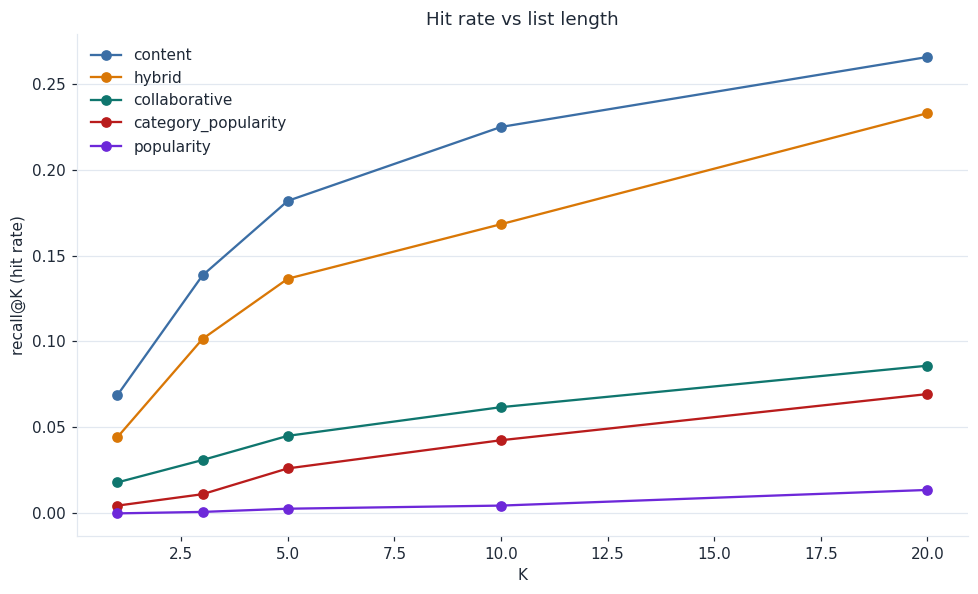

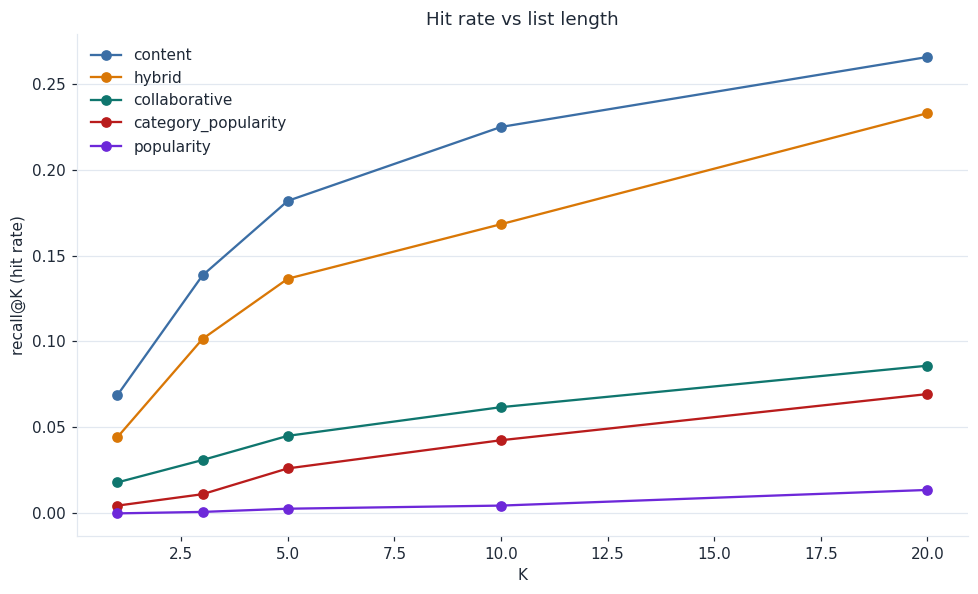

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for i, name in enumerate(comparison.index):
    ks = [1, 3, 5, 10, 20]
    vals = [evaluate_recommender(models[name], test_pairs, catalog, k=kk)[f"recall@{kk}"]
            for kk in ks]
    ax.plot(ks, vals, marker="o", color=PALETTE[i % len(PALETTE)], label=name)
ax.set_xlabel("K"); ax.set_ylabel("recall@K (hit rate)")
ax.set_title("Hit rate vs list length")
ax.legend()
fig.tight_layout()
show(fig, "recall_at_k")

In [14]:
# %% [markdown]
# ## Sanity check - look at actual recommendations

labels = category_labels(tables)
best_model = models["content"]
examples = catalog.nlargest(3, "units_sold").index.tolist()

for seed in examples:
    scat = labels.get(catalog.at[seed, "product_category_name"],
                      catalog.at[seed, "product_category_name"])
    print(f"\nSEED  {seed[:12]}  cat={scat}  price={catalog.at[seed, 'price']:.0f} "
          f"sold={catalog.at[seed, 'units_sold']}")
    for r in best_model.recommend(seed, 5):
        rcat = labels.get(catalog.at[r, "product_category_name"],
                          catalog.at[r, "product_category_name"])
        print(f"   -> {r[:12]}  cat={rcat:28s} price={catalog.at[r, 'price']:7.0f} "
              f"sold={catalog.at[r, 'units_sold']}")


SEED  aca2eb7d00ea  cat=furniture_decor  price=70 sold=527
   -> c2ece64199af  cat=furniture_decor              price=     88 sold=35
   -> 3a9fd03ce8ae  cat=furniture_decor              price=     55 sold=1
   -> 7e6efb6234cc  cat=furniture_decor              price=     90 sold=1
   -> d32c445df9d3  cat=furniture_decor              price=     66 sold=3
   -> 4a67edece2fe  cat=furniture_decor              price=     89 sold=1

SEED  99a4788cb248  cat=bed_bath_table  price=90 sold=488
   -> 321cea6c65a4  cat=bed_bath_table               price=     93 sold=2
   -> f944a3a652d3  cat=bed_bath_table               price=     90 sold=1
   -> 25f85b803dbf  cat=bed_bath_table               price=     85 sold=1
   -> aba4ddea6c5a  cat=bed_bath_table               price=     90 sold=1
   -> 84f456958365  cat=bed_bath_table               price=     92 sold=111

SEED  422879e10f46  cat=garden_tools  price=54 sold=484
   -> 53759a2ecdda  cat=garden_tools                 price=     54 sold=373
   ->

In [15]:
# %% [markdown]
# ## Save

joblib.dump({"content": models["content"], "hybrid": models["hybrid"],
             "category_weight": best_cw, "k": K,
             "test_metrics": comparison.to_dict()},
            MODELS / "recommender.joblib")
comparison.to_csv(PROCESSED / "recommender_comparison.csv")
print("saved recommender.joblib + recommender_comparison.csv")

saved recommender.joblib + recommender_comparison.csv
